First Five Rows
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape: (545, 13)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Baseline Model
Training Loss : 25104390029312.0
Validation Loss: 24544796475392.0
Test MAE : 4985707.5
Test MSE : 29843441844224.0

L1 Regularization
Training Loss : 25040565305344.0
Validation Loss: 24485218484224.0
Test MAE : 4980669.0
Test MSE : 29758893064192.0

L2 Regularization
Training Loss : 25090221670400.0
Validation Loss: 24532679131136.0
Test MAE : 4985369.0
Test MSE : 29822503878656.0

Dropout
Training Loss : 25133135691776.0
Validation Loss: 24576511705088.0
Test MAE : 4988921.5
Test MSE : 29882251739136.0

Model Comparison
      Model  Training Loss  Validation Loss   Test MAE      Test MSE
0  Baseline   2.510439e+13     2.454480e+13  4985707.5  2.984344e+13
1        L1   2.504057e+13     2.448522e+13  4980669.0  2.975889e+13
2        L2   2.509022e+13     2.453268e+13  4985369.0  2.982250e+13
3   Dropout   2.513314e+13     2.457651e+13  4988921.5  2.988225e+13


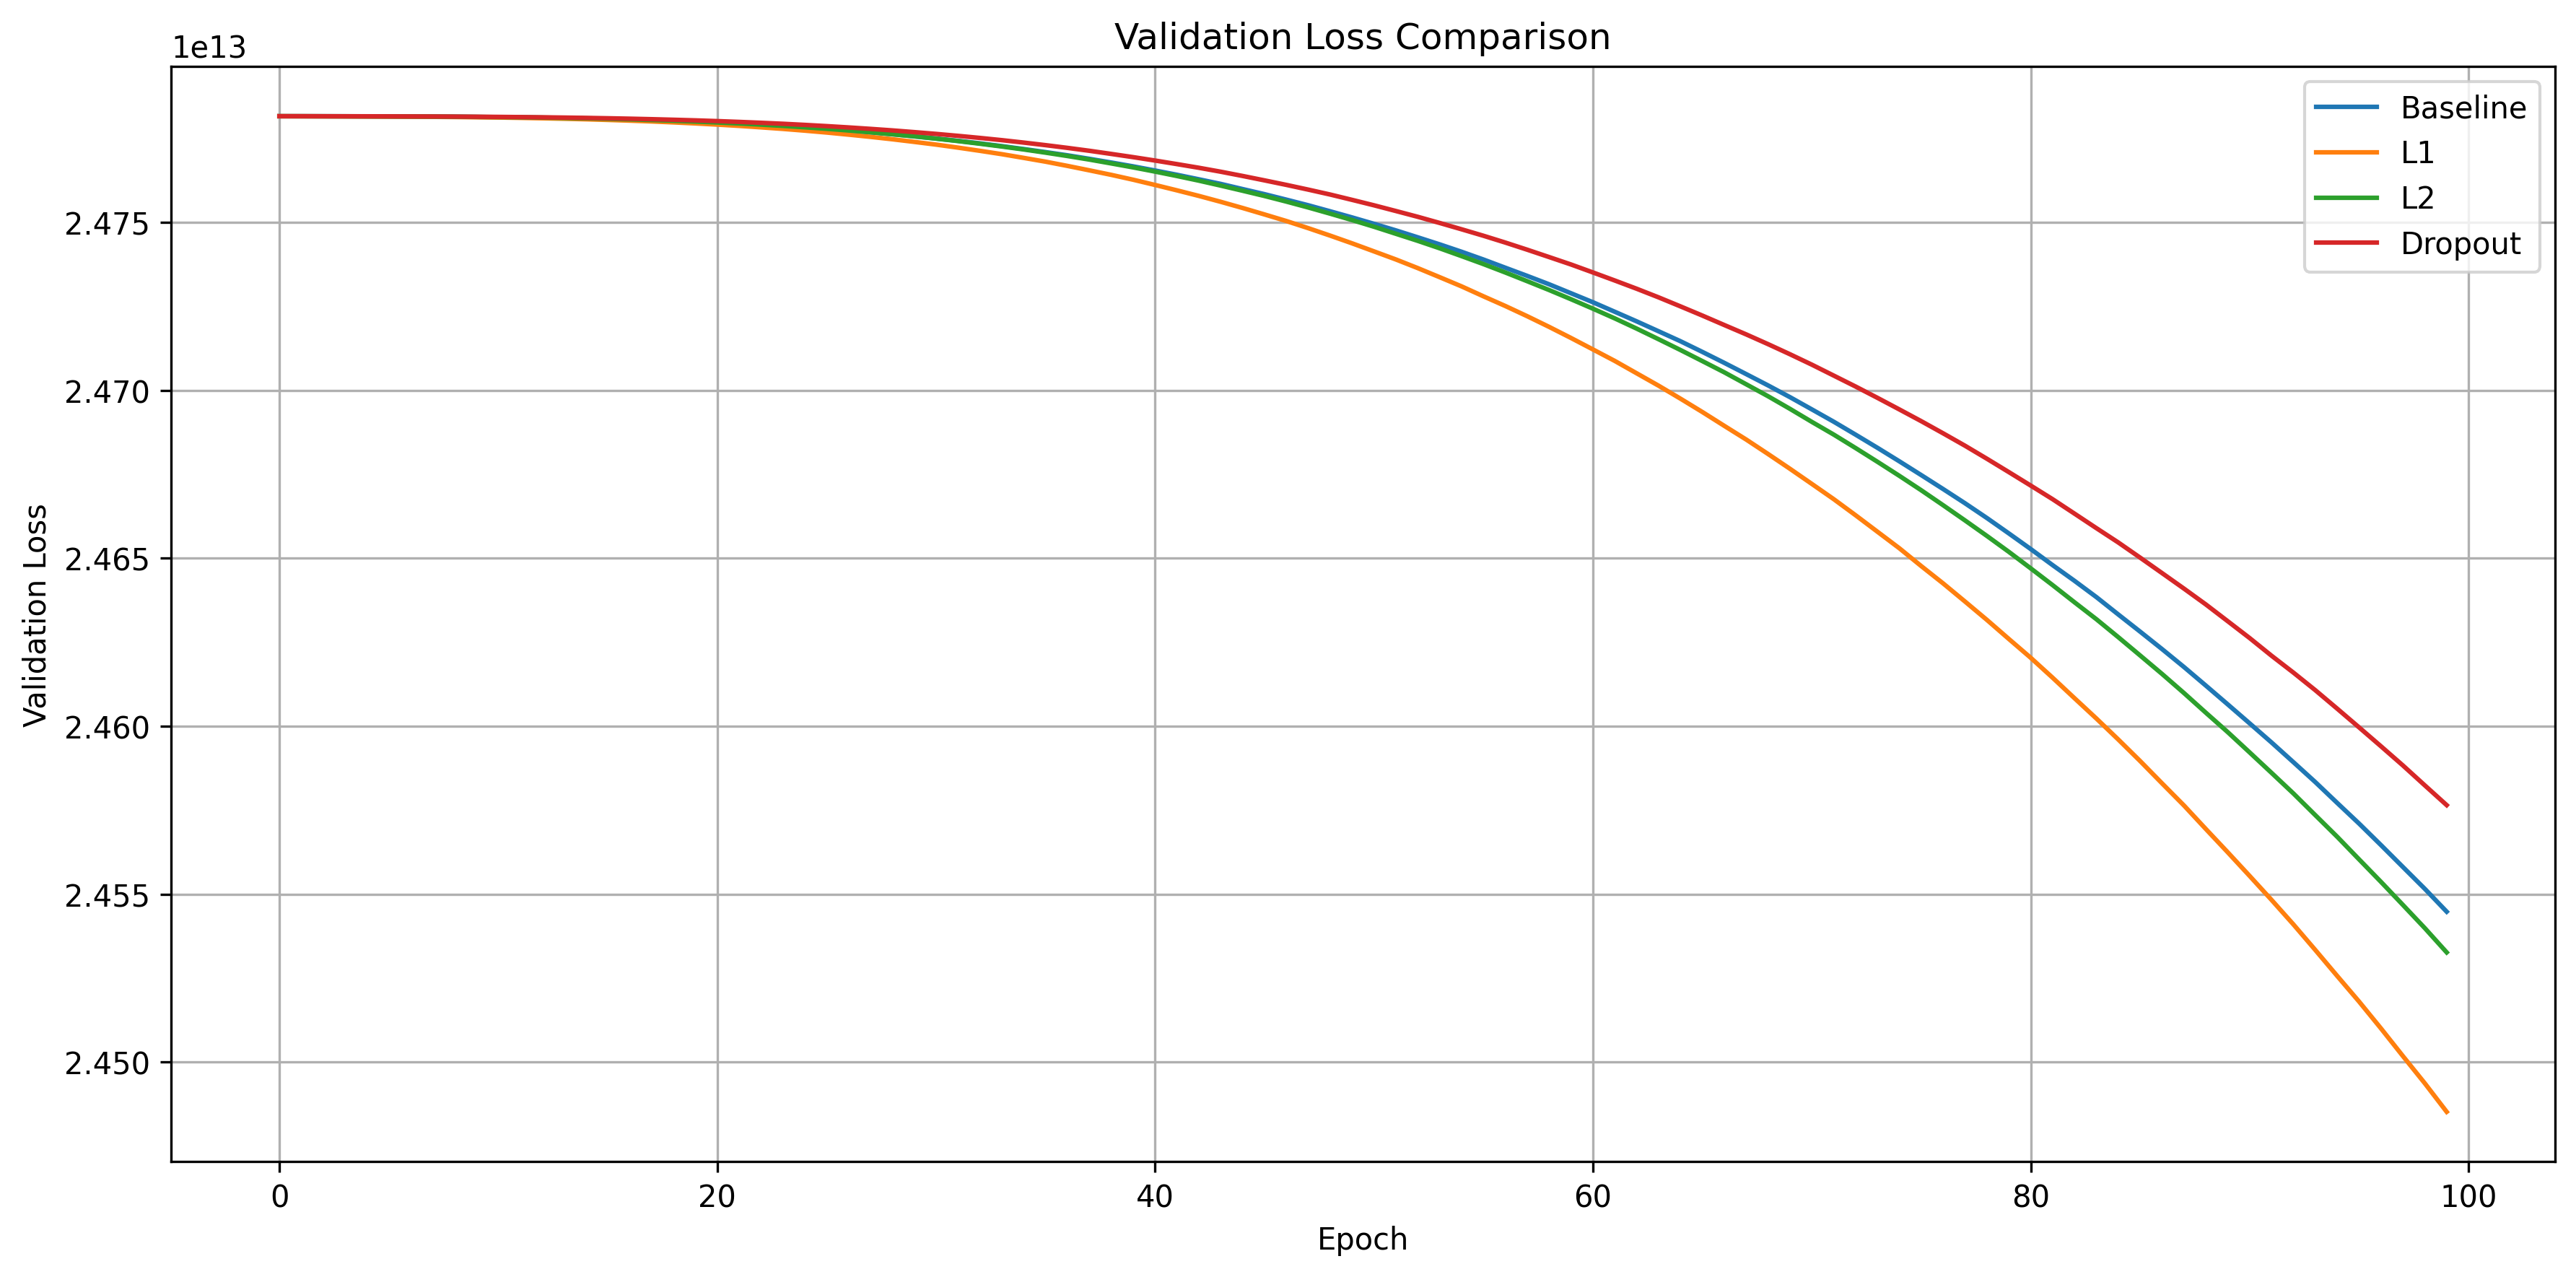

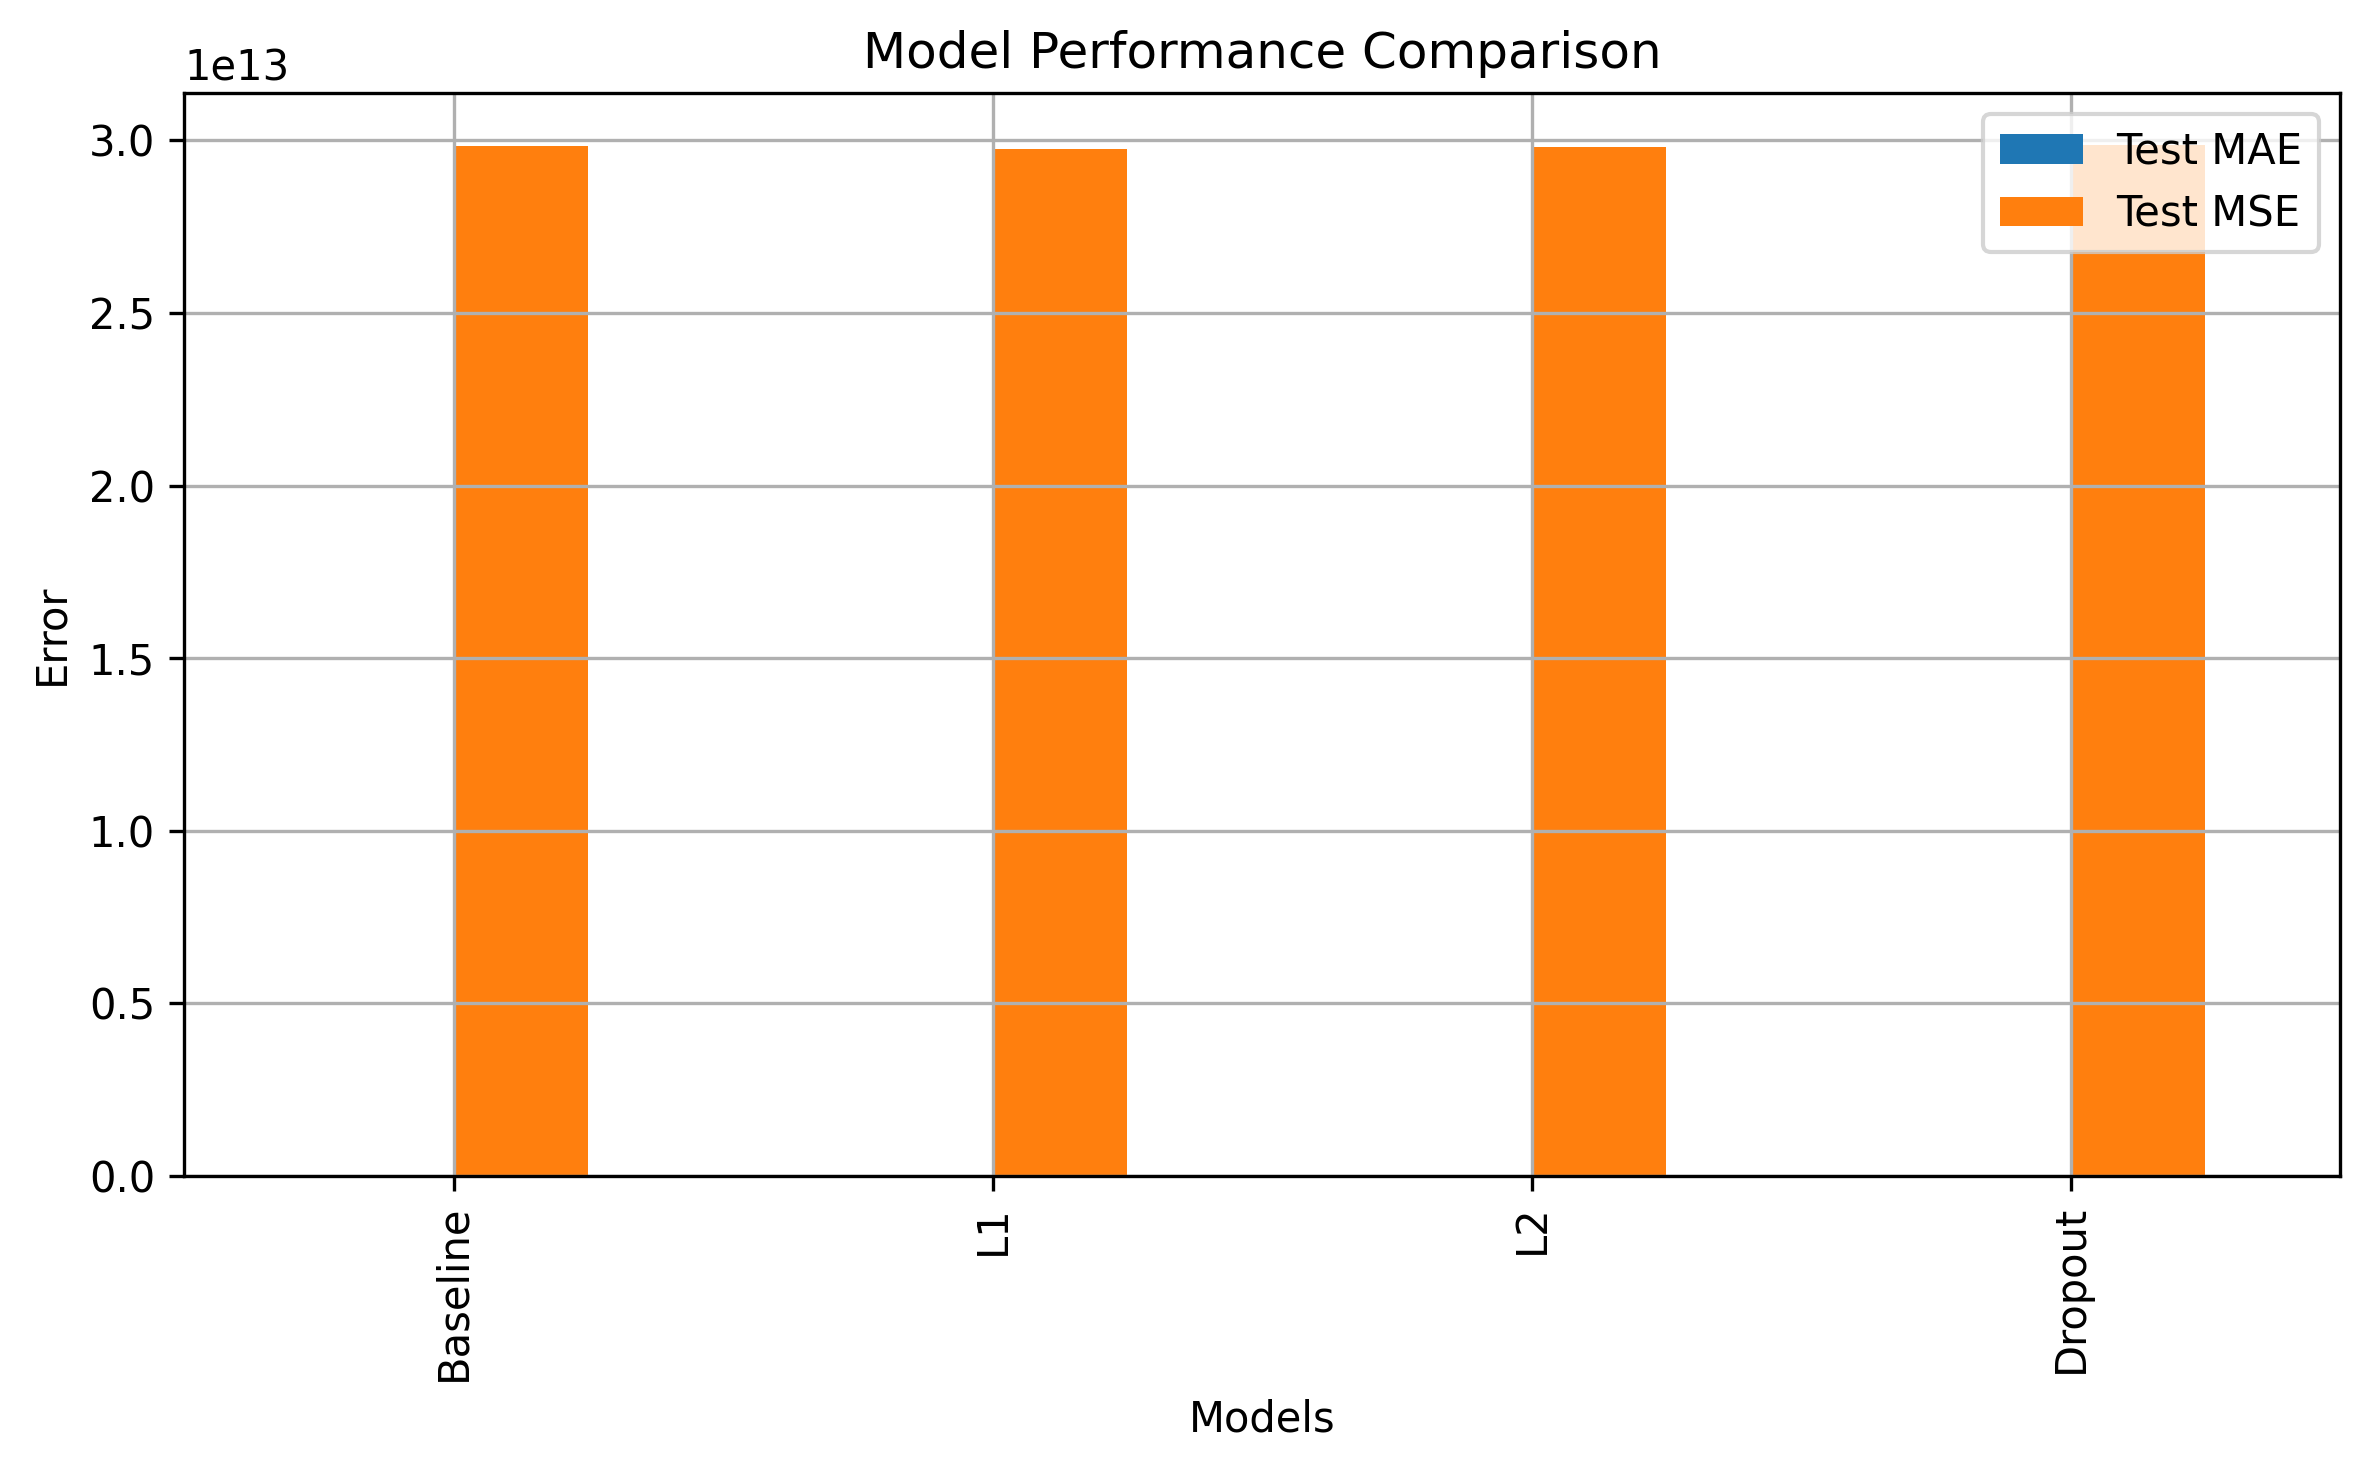

In [3]:
# ================================================================
# PRACTICAL: Regularization Techniques for Deep Learning
# Parambrata Sanyal: 23070521101
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2

# ------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------

df = pd.read_csv("Housing.csv")

print("First Five Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# ------------------------------------------------
# 2. Encode Categorical Variables
# ------------------------------------------------

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# ------------------------------------------------
# 3. Separate Features and Target
# ------------------------------------------------

X = df.drop("price", axis=1)
y = df["price"]

# ------------------------------------------------
# 4. Feature Scaling
# ------------------------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ------------------------------------------------
# 5. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------
# 6. Function to Build Models
# ------------------------------------------------

def create_model(regularizer=None, dropout=False):

    model = Sequential()

    if regularizer is None:
        model.add(Dense(
            64,
            activation='relu',
            input_shape=(X_train.shape[1],)
        ))
    else:
        model.add(Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizer,
            input_shape=(X_train.shape[1],)
        ))

    if dropout:
        model.add(Dropout(0.3))

    if regularizer is None:
        model.add(Dense(
            32,
            activation='relu'
        ))
    else:
        model.add(Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizer
        ))

    if dropout:
        model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

# ------------------------------------------------
# 7. Baseline Model
# ------------------------------------------------

baseline_model = create_model()

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# ------------------------------------------------
# 8. L1 Regularization Model
# ------------------------------------------------

l1_model = create_model(
    regularizer=l1(0.001)
)

history_l1 = l1_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# ------------------------------------------------
# 9. L2 Regularization Model
# ------------------------------------------------

l2_model = create_model(
    regularizer=l2(0.001)
)

history_l2 = l2_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# ------------------------------------------------
# 10. Dropout Model
# ------------------------------------------------

dropout_model = create_model(
    dropout=True
)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# ------------------------------------------------
# 11. Evaluation Function
# ------------------------------------------------

def evaluate(model, history, model_name):

    prediction = model.predict(X_test, verbose=0)

    mse = mean_squared_error(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)

    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print("\n===============================")
    print(model_name)
    print("===============================")
    print("Training Loss :", round(train_loss,2))
    print("Validation Loss:", round(val_loss,2))
    print("Test MAE :", round(mae,2))
    print("Test MSE :", round(mse,2))

    return train_loss, val_loss, mae, mse

# ------------------------------------------------
# 12. Evaluate All Models
# ------------------------------------------------

results = []

results.append(("Baseline",) + evaluate(
    baseline_model,
    history_baseline,
    "Baseline Model"
))

results.append(("L1",) + evaluate(
    l1_model,
    history_l1,
    "L1 Regularization"
))

results.append(("L2",) + evaluate(
    l2_model,
    history_l2,
    "L2 Regularization"
))

results.append(("Dropout",) + evaluate(
    dropout_model,
    history_dropout,
    "Dropout"
))

# ------------------------------------------------
# 13. Comparison Table
# ------------------------------------------------

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Loss",
        "Validation Loss",
        "Test MAE",
        "Test MSE"
    ]
)

print("\nModel Comparison")
print(comparison)

# ------------------------------------------------
# 14. Validation Loss Comparison Plot
# ------------------------------------------------

plt.figure(figsize=(12,6), dpi=300)

plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_l1.history['val_loss'], label='L1')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_dropout.history['val_loss'], label='Dropout')

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Validation_Loss_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------
# 15. Model Performance Comparison Plot
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(8,5), dpi=300)

comparison.set_index("Model")[["Test MAE", "Test MSE"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Error")
ax.grid(True)

plt.tight_layout()

plt.savefig(
    "Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()